In [5]:
# %% [markdown]
# # Aarki Analytics Challenge — Corrected Full Analysis (v2)
#
# The lead-quality analysis. v2 reverses one
# decision from the prior version after further investigation:
#   1. "Google" vs "google" is NOT a casing bug - it's relabeled (not merged)
#      into Google Search vs Google Content/Display, backed by independent
#      evidence from MarketingCampaign and ReferralDomain (see Section 1.2).
#      An earlier draft incorrectly merged these into one category.
#   2. Widget-naming bug (300250 vs 302252 are the SAME creative per the brief)
#      - this one IS merged, since the brief states explicitly they're identical.
#   3. Q1 trend test is censoring-aware (raw view AND resolved-only view, plus
#      a robustness check that shows whether the "trend" survives dropping the
#      least-mature month)
#   4. Driver chi-square/Cramer's V tests apply the min-sample filter BEFORE
#      computing the statistic (not just for display) - avoids the
#      high-cardinality Keyword/ReferralDomain trap
#   5. Multiple-comparison correction (FDR) across all driver tests
#   6. ROI/optimization thresholds are now percentile-based, not fixed magic
#      numbers that didn't match the data's actual scale
#   7. Adds two segments the brief explicitly hints at that were missing:
#      LandingPageURL ("where the ad was shown") and a real Search-vs-Display
#      split (built from ReferralDomain, since MarketingCampaign never
#      contains the word "content" in this dataset)
#
# Run top to bottom. Cells are marked `# %%` for Jupyter / VS Code / Spyder.

# %%
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 100)

NAVY, TEAL, ORANGE, GRAY, GOLD = "#1f3a5f", "#2a9d8f", "#e76f51", "#bdbdbd", "#e9c46a"
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#888888",
})

# >>> EDIT THIS PATH if your file lives somewhere else <<<
DATA_PATH = "shared/vinay.kapil@pw.live/Analyst_case_study_dataset_1_(1).xls"

In [6]:

# %% [markdown]
# ## Section 1 — Load & clean data
# Includes the two category-merging fixes (Partner casing, Widget naming).

# %%
df = pd.read_excel(DATA_PATH, engine="xlrd")
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("/", "_")
df["LeadCreated"] = pd.to_datetime(df["LeadCreated"])

for c in ["AddressScore", "PhoneScore"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

# %% [markdown]
# ### 1.1 Duplicate check — handled properly instead of a hard crash
#
# `VendorLeadID` has 8 missing values (NOT duplicates of each other - they're
# 8 different leads with different emails that just lack an ID; pandas
# `.duplicated()` flags repeated NaNs as "duplicates" even though they aren't).
# There is exactly ONE genuine duplicate: the same VendorLeadID, same email,
# submitted twice 43 minutes apart. We drop that one extra row and leave the
# 8 missing-ID rows alone.

# %%
has_id = df["VendorLeadID"].notna()
true_dupes = df[has_id & df["VendorLeadID"].duplicated(keep="first")]
print(f"Rows with missing VendorLeadID (not true duplicates): {df['VendorLeadID'].isna().sum()}")
print(f"True duplicate VendorLeadIDs (same ID, has a value, repeated): {len(true_dupes)}")
if len(true_dupes) > 0:
    print(true_dupes[["VendorLeadID", "LeadCreated", "Email"]])

before = len(df)
df = df.drop(index=true_dupes.index).reset_index(drop=True)
print(f"\nDropped {before - len(df)} true duplicate row(s). New row count: {len(df):,}")


Loaded 3,021 rows, 24 columns
Rows with missing VendorLeadID (not true duplicates): 8
True duplicate VendorLeadIDs (same ID, has a value, repeated): 1
                              VendorLeadID             LeadCreated                 Email
2937  33469916-C227-4A8F-BAAB-D70F7974315B 2009-05-08 17:58:24.383  jay.chalmers@att.net

Dropped 1 true duplicate row(s). New row count: 3,020


Partner values BEFORE relabeling:
google           979
yahoo            957
Google           639
Call_Center      271
AdKnowledge      171
Advertise.com      3
Name: Partner, dtype: int64

Evidence check - MarketingCampaign mix by casing:
  lowercase 'google': {'Debt Holding Tank': 338, 'Debt General': 329, 'Debt Volume': 143}
  capitalized 'Google': {'DebtReductionInc': 629, 'state': 10}

Partner values AFTER relabeling (kept separate, just renamed for clarity):
Google Search     979
yahoo             957
Google Content    639
Call_Center       271
AdKnowledge       171
Advertise.com       3
Name: Partner, dtype: int64
Sample WidgetName values BEFORE fix:
w-302252-DebtReduction1-1DC-CreditSolutions     1054
w-302252-DebtReduction1-1DC-white                430
w-300250-DebtReduction1-1DC                      348
w-302252-DebtReduction1-1DC                      271
w-302252-DebtReduction1-1DC-yellowarrow-blue     232
w-302252-DebtReduction1-1DC-yellowarrow-dark     135
Name: WidgetName,

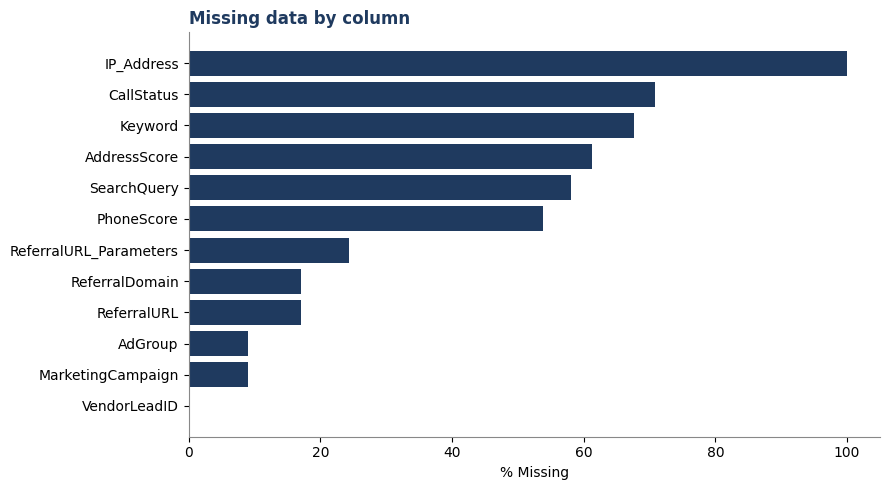

In [7]:


# %% [markdown]
# ### 1.2 CORRECTED — "Google" vs "google" is NOT a casing bug
#
#

# %%
print("Partner values BEFORE relabeling:")
print(df["Partner"].value_counts())

print("\nEvidence check - MarketingCampaign mix by casing:")
print("  lowercase 'google':", df.loc[df["Partner"] == "google", "MarketingCampaign"].value_counts().head(3).to_dict())
print("  capitalized 'Google':", df.loc[df["Partner"] == "Google", "MarketingCampaign"].value_counts().head(3).to_dict())

df["Partner"] = df["Partner"].replace({"google": "Google Search", "Google": "Google Content"})

print("\nPartner values AFTER relabeling (kept separate, just renamed for clarity):")
print(df["Partner"].value_counts())

# %% [markdown]
# ### 1.3 FIX — merge widget-naming variants (300250 / 302252)
#
# The assignment brief states explicitly: *"300250 and 302252 widgets are
# the same... w-300250-DebtReduction1-1DC is identical to
# w-302252-DebtReduction1-1DC."* Left unmerged, the same creative gets split
# into a large "ordinary" bucket and a small bucket that can look
# artificially great (or bad) purely from small-sample noise.

# %%
print("Sample WidgetName values BEFORE fix:")
print(df["WidgetName"].value_counts().head(6))

df["WidgetName"] = df["WidgetName"].str.replace("w-300250", "w-XXXXXX", regex=False)
df["WidgetName"] = df["WidgetName"].str.replace("w-302252", "w-XXXXXX", regex=False)

print("\nWidgetName values AFTER fix (merged):")
print(df["WidgetName"].value_counts())

# %% [markdown]
# ### 1.4 Data quality report

# %%
summary = pd.DataFrame({
    "Column": df.columns,
    "Type": df.dtypes.astype(str),
    "Missing": df.isna().sum(),
    "Missing_%": round(df.isna().mean() * 100, 2),
    "Unique": df.nunique(),
}).sort_values("Missing_%", ascending=False)
print(summary)

# %%
missing = df.isna().mean().sort_values(ascending=False).mul(100)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(missing.index[::-1], missing.values[::-1], color=NAVY)
ax.set_xlabel("% Missing")
ax.set_title("Missing data by column", loc="left", fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Section 2 — Categorize leads & baseline KPIs

# %%
CLOSED_STATUS = "Closed"
GOOD_NOT_CLOSED = {"EP Sent", "EP Received", "EP Confirmed"}
BAD_STATUSES = {
    "Unable to contact - Bad Contact Information",
    "Contacted - Invalid Profile",
    "Contacted - Doesn't Qualify",
}

In [8]:

def categorize_lead(status):
    if pd.isna(status):
        return "Unknown"
    if status == CLOSED_STATUS:
        return "Closed"
    if status in GOOD_NOT_CLOSED:
        return "Good"
    if status in BAD_STATUSES:
        return "Bad"
    return "Unknown"


df["Category"] = df["CallStatus"].apply(categorize_lead)
df["IsClosed"] = (df["Category"] == "Closed").astype(int)
df["IsGood"] = df["Category"].isin(["Closed", "Good"]).astype(int)   # Closed + EP-stage
df["IsBad"] = (df["Category"] == "Bad").astype(int)
df["IsUnknown"] = (df["Category"] == "Unknown").astype(int)
df["IsResolved"] = (df["Category"] != "Unknown").astype(int)

print(df["Category"].value_counts())
print()
print((df["Category"].value_counts(normalize=True) * 100).round(2))

# %%
BASE_LEADS = len(df)
BASE_CLOSED = df["IsClosed"].sum()
BASE_CLOSED_RATE = df["IsClosed"].mean()
BASE_GOOD_RATE = df["IsGood"].mean()
BASE_RESOLVED_RATE = df["IsResolved"].mean()

print("=" * 70)
print("BASELINE PERFORMANCE")
print("=" * 70)
print(f"Total Leads      : {BASE_LEADS:,}")
print(f"Closed Leads     : {BASE_CLOSED:,}")
print(f"Closed Rate      : {BASE_CLOSED_RATE:.2%}   (assignment states baseline = 8.0%)")
print(f"Good Lead Rate   : {BASE_GOOD_RATE:.2%}   (Closed + EP-stage leads)")
print(f"Resolved Rate    : {BASE_RESOLVED_RATE:.2%}   (i.e. {100-BASE_RESOLVED_RATE*100:.1f}% are still pending)")

assert 7.5 < BASE_CLOSED_RATE * 100 < 8.5, "Closed rate doesn't match the expected ~8.0% baseline - check categorization."
print("\n[OK] Matches the assignment's 8.0% baseline.")


Unknown    2139
Bad         488
Closed      245
Good        148
Name: Category, dtype: int64

Unknown    70.83
Bad        16.16
Closed      8.11
Good        4.90
Name: Category, dtype: float64
BASELINE PERFORMANCE
Total Leads      : 3,020
Closed Leads     : 245
Closed Rate      : 8.11%   (assignment states baseline = 8.0%)
Good Lead Rate   : 13.01%   (Closed + EP-stage leads)
Resolved Rate    : 29.17%   (i.e. 70.8% are still pending)

[OK] Matches the assignment's 8.0% baseline.


               Stage  Count  Percent
0          All Leads   3020   100.00
1             Closed    245     8.11
2  Good (not closed)    148     4.90
3                Bad    488    16.16
4            Unknown   2139    70.83


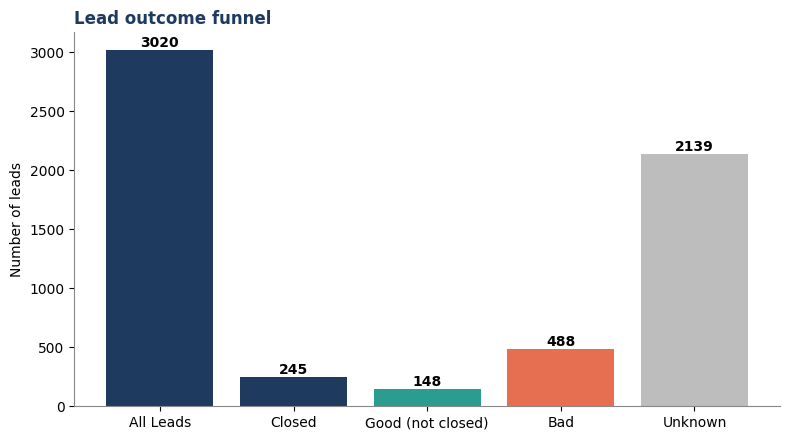

         Leads  Closed  Good  Bad  Unknown  ClosedRate_%  GoodRate_%  UnknownRate_%
Month                                                                              
2009-04    518      56    79   57      382         10.81       15.25          73.75
2009-05    579      37    59   57      463          6.39       10.19          79.97
2009-06    609      63    86  141      382         10.34       14.12          62.73
2009-07    532      33    49  110      373          6.20        9.21          70.11
2009-08    438      41    62   67      309          9.36       14.16          70.55
2009-09    344      15    58   56      230          4.36       16.86          66.86


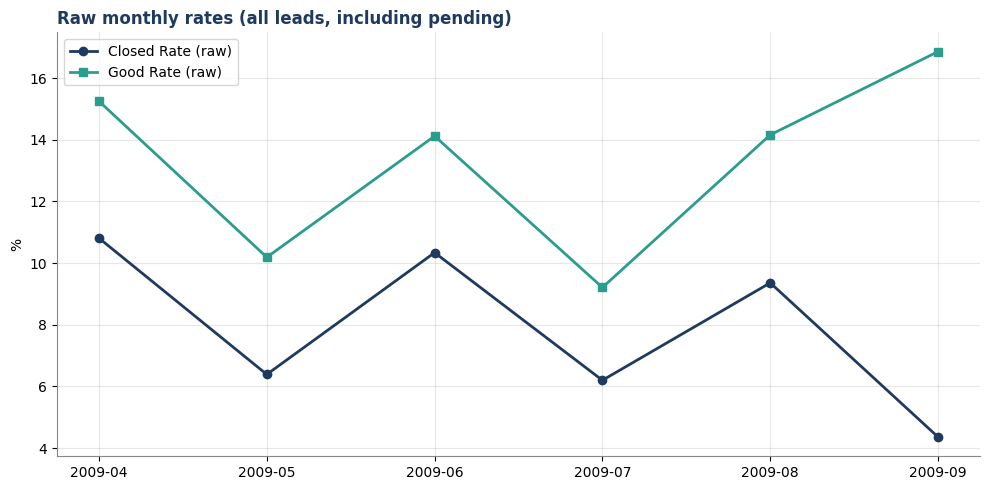

In [9]:

# %%
funnel = pd.DataFrame({
    "Stage": ["All Leads", "Closed", "Good (not closed)", "Bad", "Unknown"],
    "Count": [
        len(df),
        (df["Category"] == "Closed").sum(),
        (df["Category"] == "Good").sum(),
        (df["Category"] == "Bad").sum(),
        (df["Category"] == "Unknown").sum(),
    ],
})
funnel["Percent"] = (funnel["Count"] / len(df) * 100).round(2)
print(funnel)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [NAVY, NAVY, TEAL, ORANGE, GRAY]
bars = ax.bar(funnel["Stage"], funnel["Count"], color=colors)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{int(b.get_height())}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of leads")
ax.set_title("Lead outcome funnel", loc="left", fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Section 3 — Question 1: Is there a statistically significant quality trend?
#
# **Caveat first:** 71% of leads are still "Unknown" (pending). A lead can sit
# unresolved indefinitely, and leads created later have had less time to
# resolve. We look at the RAW view and a RESOLVED-ONLY view side by side, and
# explicitly test whether any "trend" survives once maturity is accounted for.

# %%
df["Month"] = df["LeadCreated"].dt.to_period("M").astype(str)
MONTH_ORDER = sorted(df["Month"].unique())

# %% [markdown]
# ### 3.1 Raw monthly view (all leads, including pending)

# %%
monthly_raw = (
    df.groupby("Month")
      .agg(Leads=("IsClosed", "size"), Closed=("IsClosed", "sum"),
           Good=("IsGood", "sum"), Bad=("IsBad", "sum"), Unknown=("IsUnknown", "sum"))
      .loc[MONTH_ORDER]
)
monthly_raw["ClosedRate_%"] = (monthly_raw["Closed"] / monthly_raw["Leads"] * 100).round(2)
monthly_raw["GoodRate_%"] = (monthly_raw["Good"] / monthly_raw["Leads"] * 100).round(2)
monthly_raw["UnknownRate_%"] = (monthly_raw["Unknown"] / monthly_raw["Leads"] * 100).round(2)
print(monthly_raw)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_raw.index, monthly_raw["ClosedRate_%"], marker="o", linewidth=2, label="Closed Rate (raw)", color=NAVY)
ax.plot(monthly_raw.index, monthly_raw["GoodRate_%"], marker="s", linewidth=2, label="Good Rate (raw)", color=TEAL)
ax.set_ylabel("%")
ax.set_title("Raw monthly rates (all leads, including pending)", loc="left", fontweight="bold", color=NAVY)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Resolved leads: 881 of 3,020 (29.2%)
         Leads  Good  Closed  GoodRate_%  ClosedRate_%
Month                                                 
2009-04    136    79      56        58.1          41.2
2009-05    116    59      37        50.9          31.9
2009-06    227    86      63        37.9          27.8
2009-07    159    49      33        30.8          20.8
2009-08    129    62      41        48.1          31.8
2009-09    114    58      15        50.9          13.2


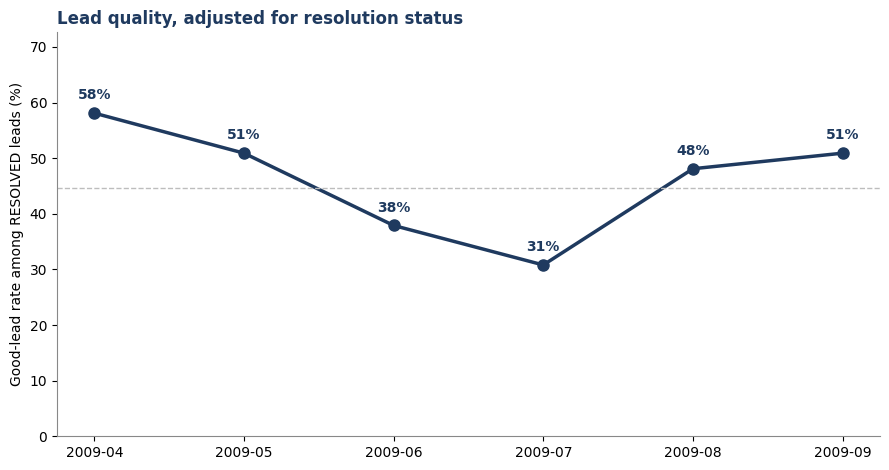

Chi-square (Month x Good/Bad, resolved leads): chi2=30.66, dof=5, p=0.000011
--> SIGNIFICANT


In [10]:


# %% [markdown]
# ### 3.2 Resolved-only view — removes most of the pending-leads noise

# %%
resolved = df[df["IsResolved"] == 1].copy()
print(f"Resolved leads: {len(resolved):,} of {len(df):,} ({len(resolved)/len(df)*100:.1f}%)")

monthly_res = (
    resolved.groupby("Month")
            .agg(Leads=("IsGood", "size"), Good=("IsGood", "sum"), Closed=("IsClosed", "sum"))
            .loc[MONTH_ORDER]
)
monthly_res["GoodRate_%"] = (monthly_res["Good"] / monthly_res["Leads"] * 100).round(1)
monthly_res["ClosedRate_%"] = (monthly_res["Closed"] / monthly_res["Leads"] * 100).round(1)
print(monthly_res)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(monthly_res.index, monthly_res["GoodRate_%"], marker="o", linewidth=2.5, markersize=8, color=NAVY)
for x, y in zip(monthly_res.index, monthly_res["GoodRate_%"]):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontweight="bold", color=NAVY)
ax.axhline(resolved["IsGood"].mean() * 100, color=GRAY, linestyle="--", linewidth=1)
ax.set_ylabel("Good-lead rate among RESOLVED leads (%)")
ax.set_title("Lead quality, adjusted for resolution status", loc="left", fontweight="bold", color=NAVY)
ax.set_ylim(0, max(monthly_res["GoodRate_%"]) * 1.25)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.3 Chi-square test — is month associated with quality at all?

# %%
ct = pd.crosstab(resolved["Month"], resolved["IsGood"])
chi2, p_chi2, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square (Month x Good/Bad, resolved leads): chi2={chi2:.2f}, dof={dof}, p={p_chi2:.6f}")
print("--> SIGNIFICANT" if p_chi2 < 0.05 else "--> not significant")



In [11]:
# %% [markdown]
# ### 3.4 Is the trend a straight line, or curved (dip then recovery)?
#
# Fit logistic regression of outcome on time as linear, then add a quadratic
# term, and compare with a likelihood-ratio test. This is the key fix versus
# the earlier draft, which only tested a linear trend and concluded "decline"
# from that alone.

# %%
resolved["DayNum"] = (resolved["LeadCreated"] - resolved["LeadCreated"].min()).dt.days
resolved["DayNum_c"] = resolved["DayNum"] - resolved["DayNum"].mean()
resolved["DayNum_c2"] = resolved["DayNum_c"] ** 2

linear_model = smf.logit("IsGood ~ DayNum_c", data=resolved).fit(disp=0)
quad_model = smf.logit("IsGood ~ DayNum_c + DayNum_c2", data=resolved).fit(disp=0)

print("LINEAR time-trend model:")
print(linear_model.summary2().tables[1])
print("\nQUADRATIC (curved) time-trend model:")
print(quad_model.summary2().tables[1])

lr_stat = 2 * (quad_model.llf - linear_model.llf)
lr_p = stats.chi2.sf(lr_stat, df=1)
print(f"\nLikelihood-ratio test (quadratic vs linear): LR={lr_stat:.2f}, p={lr_p:.6f}")
print("--> Curved fit is significantly better than a straight line" if lr_p < 0.05 else "--> No improvement from curvature")

# %% [markdown]
# ### 3.5 Robustness check — does a SIMPLE LINEAR trend on the RAW (all-leads)
# data survive once you drop the least-mature month(s)?
#
# This directly tests whether a naive "closed rate is declining" linear-trend
# finding (using ALL leads, unresolved included) is real or is being driven
# by the newest, least-resolved cohort looking artificially low.

# %%
print("Linear trend on RAW IsClosed ~ MonthIndex, all leads, as more recent")
print("(least-mature / most-censored) months are progressively excluded:\n")
for exclude in [[], [MONTH_ORDER[-1]], MONTH_ORDER[-2:], MONTH_ORDER[-3:]]:
    sub = df[~df["Month"].isin(exclude)].copy()
    sub["MonthIndex"] = sub["Month"].astype("category").cat.codes
    X = sm.add_constant(sub["MonthIndex"])
    m = sm.Logit(sub["IsClosed"], X).fit(disp=0)
    label = "none" if not exclude else ", ".join(exclude)
    print(f"  Excluding [{label}]: n={len(sub)}, coef={m.params['MonthIndex']:.4f}, p={m.pvalues['MonthIndex']:.4f}")
print("\nIf the p-value collapses once the newest month(s) are dropped, the")
print("'declining trend' is being driven by censoring, not genuine quality decline.")


LINEAR time-trend model:
              Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
Intercept -0.217445  0.067927 -3.201171  0.001369 -0.350578 -0.084311
DayNum_c  -0.002687  0.001400 -1.918859  0.055002 -0.005432  0.000058

QUADRATIC (curved) time-trend model:
              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -0.533566  0.097164 -5.491392  3.987789e-08 -0.724004 -0.343128
DayNum_c  -0.003394  0.001417 -2.395484  1.659842e-02 -0.006170 -0.000617
DayNum_c2  0.000133  0.000029  4.624686  3.751661e-06  0.000076  0.000189

Likelihood-ratio test (quadratic vs linear): LR=21.80, p=0.000003
--> Curved fit is significantly better than a straight line
Linear trend on RAW IsClosed ~ MonthIndex, all leads, as more recent
(least-mature / most-censored) months are progressively excluded:

  Excluding [none]: n=3020, coef=-0.0976, p=0.0207
  Excluding [2009-09]: n=2676, coef=-0.0420, p=0.4098
  Excluding [2009-08, 2009-09]: n=2238, coef=-0.1196, p=0.0875


Bad rate among ALL leads, by month:
Month
2009-04    11.0
2009-05     9.8
2009-06    23.2
2009-07    20.7
2009-08    15.3
2009-09    16.3
Name: IsBad, dtype: float64
Partner  AdKnowledge  Advertise.com  Call_Center  Google Content  Google Search  yahoo
Month                                                                                 
2009-04          9.3            0.0          7.9            13.9           29.9   39.0
2009-05          5.7            0.5          7.6            17.3           27.6   41.3
2009-06          4.8            0.0          9.9            20.4           28.6   36.5
2009-07          2.1            0.0         10.3            36.5           34.0   17.1
2009-08          6.8            0.0          8.0            21.5           42.0   21.7
2009-09          5.8            0.0         10.5            16.0           36.3   31.4


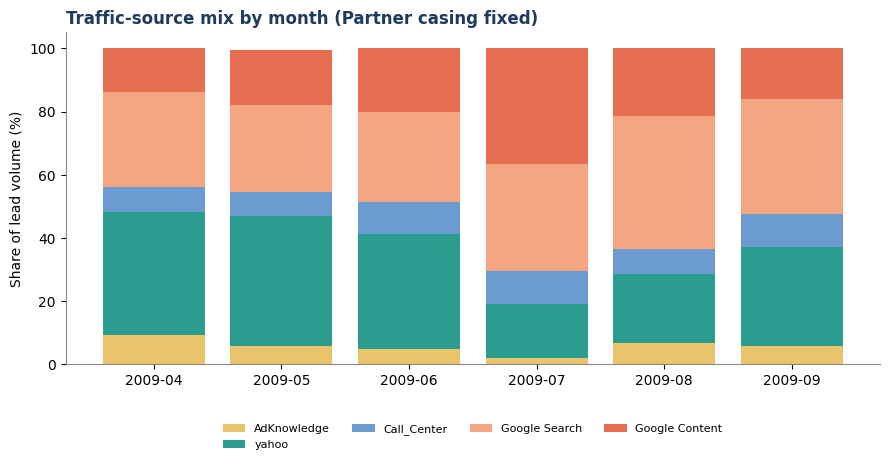

                                 Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
Intercept                    -0.525707  0.326663 -1.609324  0.107546 -1.165956  0.114541
C(Partner)[T.Call_Center]    -0.489265  0.344755 -1.419165  0.155851 -1.164972  0.186443
C(Partner)[T.Google Content] -0.911792  0.337541 -2.701276  0.006907 -1.573360 -0.250223
C(Partner)[T.Google Search]  -0.393179  0.304680 -1.290465  0.196889 -0.990342  0.203983
C(Partner)[T.yahoo]          -0.389918  0.305165 -1.277726  0.201346 -0.988031  0.208196
DebtMid_k                     0.029712  0.008491  3.499190  0.000467  0.013070  0.046355
DebtMid_k2                   -0.000267  0.000072 -3.681258  0.000232 -0.000409 -0.000125
DayNum_c                     -0.002922  0.001458 -2.004340  0.045034 -0.005780 -0.000065
DayNum_c2                     0.000125  0.000029  4.231251  0.000023  0.000067  0.000182

If DayNum_c2 is still significant here, the dip/recovery isn't fully
explained by partner+debt mix alone - th

In [12]:


# %% [markdown]
# ### 3.6 Censoring-robust check — Bad rate on ALL leads (no filtering needed)
#
# A "Bad" outcome (disconnected number, wrong person, doesn't qualify) is
# usually resolved with a single phone call, so it is much less sensitive to
# how much time a lead has had to mature. If this metric shows the same
# dip-and-recovery shape as the resolved-only Good rate, that's independent
# confirmation the pattern is real and not just a resolved-only-subset artifact.

# %%
bad_by_month = (df.groupby("Month")["IsBad"].mean() * 100).loc[MONTH_ORDER]
print("Bad rate among ALL leads, by month:")
print(bad_by_month.round(1))

# %% [markdown]
# ### 3.7 What's behind the dip — traffic-source mix shift by month

# %%
partner_mix = (pd.crosstab(df["Month"], df["Partner"], normalize="index").loc[MONTH_ORDER] * 100).round(1)
print(partner_mix)

plot_cols = [c for c in ["AdKnowledge", "yahoo", "Call_Center", "Google Search", "Google Content"] if c in partner_mix.columns]
fig, ax = plt.subplots(figsize=(9, 4.8))
bottom = np.zeros(len(partner_mix))
pcolors = {"AdKnowledge": GOLD, "yahoo": TEAL, "Call_Center": "#6c9bd1", "Google Search": "#f4a582", "Google Content": ORANGE}
for col in plot_cols:
    ax.bar(partner_mix.index, partner_mix[col], bottom=bottom, label=col, color=pcolors[col])
    bottom += partner_mix[col].values
ax.set_ylabel("Share of lead volume (%)")
ax.set_title("Traffic-source mix by month (Partner casing fixed)", loc="left", fontweight="bold", color=NAVY)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.8 Does the time pattern survive controlling for partner & debt mix?

# %%
DEBT_MIDPOINTS = {
    "7500-10000": 8750, "7500-15000": 11250, "10001-15000": 12500, "15001-20000": 17500,
    "20001-30000": 25000, "30001-50000": 40000, "50001-70000": 60000, "70001-90000": 80000,
    "90000-100000": 95000, "More_than_100000": 120000,
}
resolved["DebtMid_k"] = resolved["DebtLevel"].map(DEBT_MIDPOINTS) / 1000
resolved["DebtMid_k2"] = resolved["DebtMid_k"] ** 2
resolved_ctrl = resolved[resolved["Partner"] != "Advertise.com"].copy()  # n=1, drop to avoid singular matrix

controlled_model = smf.logit(
    "IsGood ~ DebtMid_k + DebtMid_k2 + C(Partner) + DayNum_c + DayNum_c2",
    data=resolved_ctrl,
).fit(disp=0)
print(controlled_model.summary2().tables[1])
print(f"\nIf DayNum_c2 is still significant here, the dip/recovery isn't fully")
print(f"explained by partner+debt mix alone - there's a residual time effect too.")



In [13]:
# %% [markdown]
# ## Section 4 — Question 2: What drives lead quality?
#
# Key fix vs. the earlier draft: the minimum-sample filter is applied
# **before** computing chi-square/Cramer's V (not just for display), so
# high-cardinality, mostly-missing columns (Keyword: 285 values, 68% missing;
# ReferralDomain: 372 values, 17% missing) can't produce an inflated,
# statistically-invalid effect size.

# %%
OVERALL_CLOSED = df["IsClosed"].mean()
OVERALL_GOOD = df["IsGood"].mean()


def analyze_driver(data, column, min_leads=30, outcome="IsGood"):
    """Chi-square + Cramer's V computed ONLY on categories with >= min_leads,
    so sparse/high-cardinality columns can't produce a spurious effect size."""
    counts = data[column].value_counts(dropna=False)
    keep_categories = counts[counts >= min_leads].index
    filtered = data[data[column].isin(keep_categories)].copy()

    temp = (
        filtered.groupby(column, dropna=False)
                .agg(Leads=("IsClosed", "size"), Closed=("IsClosed", "sum"), Good=("IsGood", "sum"))
                .reset_index()
    )
    temp["ClosedRate"] = temp["Closed"] / temp["Leads"]
    temp["GoodRate"] = temp["Good"] / temp["Leads"]
    temp["ClosedLift_%"] = ((temp["ClosedRate"] / OVERALL_CLOSED - 1) * 100).round(1)
    temp["TrafficShare_%"] = (temp["Leads"] / len(data) * 100).round(1)

    if len(keep_categories) > 1:
        contingency = pd.crosstab(filtered[column], filtered[outcome], dropna=False)
        chi2, p, _, expected = stats.chi2_contingency(contingency)
        n = contingency.values.sum()
        r, k = contingency.shape
        cramers_v = np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1))
        min_expected = expected.min()
    else:
        chi2, p, cramers_v, min_expected = np.nan, np.nan, np.nan, np.nan

    n_dropped = data[column].notna().sum() - filtered[column].notna().sum() if column in data else 0
    temp = temp.sort_values("ClosedRate", ascending=False)
    return temp, p, cramers_v, min_expected, len(keep_categories), n_dropped


print("Driver analysis function ready. min_leads filter is applied to the")
print("statistical test itself, not just the display table.")

# %% [markdown]
# ### 4.1 Run every candidate driver, collect p-values for multiple-testing correction


Driver analysis function ready. min_leads filter is applied to the
statistical test itself, not just the display table.


In [14]:
# %%
DRIVER_COLUMNS = {
    "DebtLevel": 20,
    "Partner": 30,          # now correctly split into Google Search vs Google Content
    "WidgetName": 30,       # now correctly merged (300250/302252)
    "AddressScore": 20,
    "PhoneScore": 20,
    "State": 30,
    "AdvertiserCampaignName": 30,   # branded vs generic copy
    "PublisherCampaignName": 30,    # call center vs online entry channel
}

driver_results = {}
for col, min_n in DRIVER_COLUMNS.items():
    driver_results[col] = analyze_driver(df, col, min_leads=min_n)

rows = []
for col, (table, p, cv, min_exp, n_cats, n_dropped) in driver_results.items():
    rows.append({
        "Driver": col, "Categories_kept": n_cats, "Leads_excluded_too_small": n_dropped,
        "p_value": p, "Cramers_V": cv, "Min_expected_cell": min_exp,
    })
driver_summary = pd.DataFrame(rows).sort_values("p_value")
print(driver_summary)

# %% [markdown]
# ### 4.2 Multiple-comparisons correction (Benjamini-Hochberg FDR)
#
# We ran 8 tests. At p<0.05 each, you'd expect roughly one false positive by
# chance alone if none of the effects were real. FDR correction is the
# standard, less-conservative-than-Bonferroni adjustment for this.

# %%
valid = driver_summary.dropna(subset=["p_value"])
reject, p_adj, _, _ = multipletests(valid["p_value"], alpha=0.05, method="fdr_bh")
driver_summary.loc[valid.index, "FDR_adjusted_p"] = p_adj
driver_summary.loc[valid.index, "Survives_FDR"] = reject
print(driver_summary[["Driver", "p_value", "FDR_adjusted_p", "Survives_FDR", "Cramers_V"]].sort_values("p_value"))

# %% [markdown]
# ### 4.3 Detail tables for the drivers that survive

                   Driver  Categories_kept  Leads_excluded_too_small   p_value  Cramers_V  Min_expected_cell
1                 Partner                5                         3  0.000007   0.098536          22.218097
0               DebtLevel               10                         0  0.000016   0.112561          11.711921
4              PhoneScore                5                         1  0.004026   0.097758          20.831897
7   PublisherCampaignName                2                         0  0.119181   0.028355          35.265894
5                   State               22                       179  0.180742   0.096958           4.167547
2              WidgetName               11                         0  0.181243   0.067653           6.376490
3            AddressScore                6                         0  0.203027   0.071273           4.932536
6  AdvertiserCampaignName                2                         0  1.000000   0.000000         156.939735
                   

In [15]:



# %%
for col in ["DebtLevel", "Partner", "WidgetName"]:
    table, p, cv, min_exp, n_cats, n_dropped = driver_results[col]
    print("=" * 80)
    print(f"{col}   (p={p:.5f}, Cramer's V={cv:.3f}, categories kept={n_cats}, leads excluded for being too small={n_dropped})")
    print("=" * 80)
    print(table[[col, "Leads", "ClosedRate", "GoodRate", "ClosedLift_%", "TrafficShare_%"]].to_string(index=False))
    print()

# %% [markdown]
# ### 4.4 Why Keyword / ReferralDomain are EXCLUDED from the driver ranking
#
# Demonstration of the high-cardinality trap: compute Cramer's V the "naive"
# way (no minimum-sample filter) vs. the corrected way, on Keyword.

# %%
naive_ct = pd.crosstab(df["Keyword"], df["IsGood"])
chi2_naive, p_naive, _, exp_naive = stats.chi2_contingency(naive_ct)
n = exp_naive.sum()
cv_naive = np.sqrt((chi2_naive / n) / 1)
print(f"Keyword, NAIVE (no min-sample filter): {naive_ct.shape[0]} categories, "
      f"min expected cell count={exp_naive.min():.3f}, Cramer's V={cv_naive:.3f}, p={p_naive:.4f}")
print("--> Min expected cell count far below the 5-per-cell rule of thumb for chi-square")
print("    validity. This inflated V is a sparse-table artifact, not a real driver.")
print()
table, p, cv, min_exp, n_cats, n_dropped = analyze_driver(df, "Keyword", min_leads=30, outcome="IsGood")
print(f"Keyword, CORRECTED (min_leads=30 applied before the test): only {n_cats} categories survive,")
print(f"Cramer's V={cv}, p={p}  <- with this few categories left, treat as inconclusive, not a finding.")

# %% [markdown]
# ### 4.5 NEW — segments the brief calls out that were missing: landing page
# and a real search-vs-display split

# %%

DebtLevel   (p=0.00002, Cramer's V=0.113, categories kept=10, leads excluded for being too small=0)
       DebtLevel  Leads  ClosedRate  GoodRate  ClosedLift_%  TrafficShare_%
     70001-90000    131    0.137405  0.190840          69.4             4.3
     10001-15000    291    0.116838  0.185567          44.0             9.6
    90000-100000     90    0.100000  0.122222          23.3             3.0
     50001-70000    245    0.089796  0.155102          10.7             8.1
     20001-30000    456    0.087719  0.157895           8.1            15.1
     15001-20000    408    0.085784  0.139706           5.7            13.5
     30001-50000    496    0.078629  0.122984          -3.1            16.4
      7500-15000    271    0.070111  0.114391         -13.6             9.0
      7500-10000    442    0.049774  0.070136         -38.6            14.6
More_than_100000    190    0.036842  0.068421         -54.6             6.3

Partner   (p=0.00001, Cramer's V=0.099, categories kept=5, lead

In [16]:
def page_name(url):
    if "callcenter" in url.lower() or "inadcoad" in url.lower():
        return "Call Center"
    for tag in ["index8", "index11", "index12"]:
        if tag in url:
            return tag
    return "other"


df["LandingPage"] = df["LandingPageURL"].apply(page_name)
web_only = df[df["LandingPage"] != "Call Center"]

table, p, cv, min_exp, n_cats, n_dropped = analyze_driver(web_only, "LandingPage", min_leads=30, outcome="IsGood")
print("LandingPage (web leads only - call center excluded as it's a separate channel already tested):")
print(f"p={p:.5f}, Cramer's V={cv:.3f}")
print(table[["LandingPage", "Leads", "ClosedRate", "GoodRate", "ClosedLift_%"]].to_string(index=False))


LandingPage (web leads only - call center excluded as it's a separate channel already tested):
p=0.00192, Cramer's V=0.067
LandingPage  Leads  ClosedRate  GoodRate  ClosedLift_%
     index8   2539    0.083104  0.133123           2.4
    index11     86    0.069767  0.081395         -14.0
    index12    124    0.016129  0.032258         -80.1


In [17]:

# %%
SEARCH_DOMAINS = ["google.com", "search.yahoo.com", "bing.com", "search.aol.com", "ask.com",
                  "mywebsearch.com", "webcrawler.com", "searchportal.information.com"]
AD_NETWORK_DOMAINS = ["doubleclick.net", "googlesyndication.com"]


def classify_traffic(row):
    if row["PublisherCampaignName"] == "DebtReductionCallCenter":
        return "Call Center (phone)"
    dom = row["ReferralDomain"]
    if pd.isna(dom):
        return "Direct/Unknown"
    dom = str(dom).lower()
    if any(s in dom for s in AD_NETWORK_DOMAINS):
        return "Display/Content network ad"
    if any(s in dom for s in SEARCH_DOMAINS):
        return "Search results page"
    if dom == "www.debtreductioninc.com":
        return "Direct/Unknown"
    return "Content/article site"


df["TrafficType"] = df.apply(classify_traffic, axis=1)
table, p, cv, min_exp, n_cats, n_dropped = analyze_driver(df, "TrafficType", min_leads=30, outcome="IsGood")
print("TrafficType (built from ReferralDomain - NOTE: the original 'content' keyword")
print("search on MarketingCampaign never matches anything in this data and silently")
print("classifies 100% of leads as 'Search' - this version actually differentiates):")
print(f"p={p:.5f}, Cramer's V={cv:.3f}")
print(table[["TrafficType", "Leads", "ClosedRate", "GoodRate", "ClosedLift_%"]].to_string(index=False))

# %% [markdown]
# ### 4.6 Confounding check (Simpson's paradox) — does the debt-level effect
# hold WITHIN each major traffic source, or could it just be a Partner artifact?

# %%
df["DebtMid"] = df["DebtLevel"].map(DEBT_MIDPOINTS)
df["DebtBand"] = pd.cut(df["DebtMid"], bins=[0, 10000, 90000, 200000], labels=["low", "sweet", "high"])

for partner in ["Google Search", "Google Content", "yahoo", "AdKnowledge", "Call_Center"]:
    sub = df[df["Partner"] == partner]
    g = sub.groupby("DebtBand")["IsClosed"].agg(["mean", "count"])
    g["mean"] = (g["mean"] * 100).round(2)
    print(f"--- {partner} (n={len(sub)}) ---")
    print(g)
    print()

# %% [markdown]
# ## Section 5 — Question 3: Can we realistically go from 8.0% to 9.6%?

# %% [markdown]
# ### 5.1 Direct lever sizing against historical data, with 95% confidence intervals

# %%
scenarios = {
    "Baseline (all leads)": df["IsClosed"].sum(), }
scenario_n = {"Baseline (all leads)": len(df)}

sweet = df[df["DebtBand"] == "sweet"]
scenarios["Debt sweet-spot only ($10k-$90k)"] = sweet["IsClosed"].sum()
scenario_n["Debt sweet-spot only ($10k-$90k)"] = len(sweet)

adk = df[df["Partner"] == "AdKnowledge"]
scenarios["AdKnowledge traffic only"] = adk["IsClosed"].sum()
scenario_n["AdKnowledge traffic only"] = len(adk)

cc = df[df["Partner"] == "Call_Center"]
scenarios["Call Center channel only"] = cc["IsClosed"].sum()
scenario_n["Call Center channel only"] = len(cc)

combo = sweet[sweet["Partner"].isin(["AdKnowledge", "Call_Center"])]
scenarios["Combined: sweet-spot debt + AdKnowledge/Call Center"] = combo["IsClosed"].sum()
scenario_n["Combined: sweet-spot debt + AdKnowledge/Call Center"] = len(combo)

drop_content = df[df["Partner"] != "Google Content"]
scenarios["Drop Google Content (keep Search/Yahoo/AdK/CallCtr)"] = drop_content["IsClosed"].sum()
scenario_n["Drop Google Content (keep Search/Yahoo/AdK/CallCtr)"] = len(drop_content)

combo_all = sweet[sweet["Partner"] != "Google Content"]
scenarios["Combined: sweet-spot debt + drop Google Content"] = combo_all["IsClosed"].sum()
scenario_n["Combined: sweet-spot debt + drop Google Content"] = len(combo_all)

print(f"{'Scenario':55s} {'n':>6s} {'Rate':>8s} {'95% CI':>18s}")
for label in scenarios:
    x, n = scenarios[label], scenario_n[label]
    lo, hi = proportion_confint(x, n, alpha=0.05, method="wilson")
    print(f"{label:55s} {n:6d} {x/n*100:7.2f}%  ({lo*100:5.2f}%, {hi*100:5.2f}%)")

print(f"\nTarget: 9.6% (a +20% relative lift on the 8.0% baseline)")


TrafficType (built from ReferralDomain - NOTE: the original 'content' keyword
search on MarketingCampaign never matches anything in this data and silently
classifies 100% of leads as 'Search' - this version actually differentiates):
p=0.00789, Cramer's V=0.068
               TrafficType  Leads  ClosedRate  GoodRate  ClosedLift_%
       Call Center (phone)    271    0.095941  0.162362          18.3
       Search results page   1292    0.093653  0.147059          15.4
            Direct/Unknown    263    0.079848  0.098859          -1.6
      Content/article site    876    0.068493  0.119863         -15.6
Display/Content network ad    318    0.053459  0.088050         -34.1
--- Google Search (n=979) ---
           mean  count
DebtBand              
low        6.17    162
sweet     10.79    732
high       9.41     85

--- Google Content (n=639) ---
          mean  count
DebtBand             
low       3.30     91
sweet     4.71    467
high      1.23     81

--- yahoo (n=957) ---
         

In [18]:


# %% [markdown]
# ### 5.2 Honesty check — how much data would a clean test actually need to
# PROVE an 8.0% -> 9.6% lift, before committing budget to it?

# %%
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect = proportion_effectsize(0.096, 0.080)
n_per_group = NormalIndPower().solve_power(effect_size=effect, alpha=0.05, power=0.80, ratio=1, alternative="two-sided")
print(f"Required sample size per group for 80% power at alpha=0.05: {n_per_group:.0f}")
print(f"Total leads needed for a clean A/B test: ~{2*n_per_group:.0f}")
print(f"This dataset has {len(df):,} leads - useful for sizing promising levers,")
print(f"but a forward test should still confirm before a full budget commitment.")

# %% [markdown]
# ### 5.3 Corrected traffic/ad-group reallocation simulator
#
# Fix vs. the earlier draft: thresholds for "increase/test/reduce" are now
# **percentile-based** (computed from the actual distribution of ROI scores),
# instead of fixed numbers that didn't match the data's real scale.

# %%
def opportunity_table(data, column, min_leads=30):
    g = (data.groupby(column, dropna=False)
             .agg(Leads=("IsClosed", "size"), Closed=("IsClosed", "sum"), Good=("IsGood", "sum"))
             .reset_index())
    g = g[g["Leads"] >= min_leads].copy()
    g["ClosedRate"] = g["Closed"] / g["Leads"]
    g["GoodRate"] = g["Good"] / g["Leads"]
    g["ClosedLift_%"] = (g["ClosedRate"] / OVERALL_CLOSED - 1) * 100
    g["TrafficShare_%"] = g["Leads"] / len(data) * 100
    return g


def reallocation_plan(data, column, move_percent=20, min_leads=30, cpl=33):
    opp = opportunity_table(data, column, min_leads=min_leads)
    overall_rate = data["IsClosed"].mean()
    good_segs = opp[opp["ClosedRate"] > overall_rate]
    poor_segs = opp[opp["ClosedRate"] < overall_rate]

    rows = []
    for _, poor in poor_segs.iterrows():
        moved = round(poor["Leads"] * move_percent / 100)
        current_closed = moved * poor["ClosedRate"]
        for _, good in good_segs.iterrows():
            expected_closed = moved * good["ClosedRate"]
            gain = expected_closed - current_closed
            rows.append({
                "Driver": column, "Move_From": poor[column], "Move_To": good[column],
                "Leads_Shifted": moved, "Extra_Customers": gain, "Extra_Revenue": gain * cpl,
                "Budget_Needed": moved * cpl,
            })
    result = pd.DataFrame(rows)
    if len(result) == 0:
        return result
    # FIX: percentile-based thresholds instead of fixed magic numbers
    result["ROI_Score"] = result["Extra_Customers"] / result["Budget_Needed"]
    q75, q40, q15 = result["ROI_Score"].quantile([0.75, 0.40, 0.15])
    conditions = [result["ROI_Score"] >= q75, result["ROI_Score"] >= q40, result["ROI_Score"] >= q15]
    choices = ["Increase Aggressively", "Increase", "Test"]
    result["Recommendation"] = np.select(conditions, choices, default="Reduce/Avoid")
    return result.sort_values("Extra_Customers", ascending=False)


business_drivers = ["Partner", "WidgetName", "DebtLevel", "AdvertiserCampaignName"]
all_plans = []
for d in business_drivers:
    plan = reallocation_plan(df, d, move_percent=20, min_leads=30)
    if len(plan) > 0:
        all_plans.append(plan)
        print(f"\n{'='*90}\n{d}\n{'='*90}")
        print(plan.head(8).to_string(index=False))

full_plan = pd.concat(all_plans, ignore_index=True) if all_plans else pd.DataFrame()

# %% [markdown]
# ### 5.4 Constrained budget plan — pick the best non-overlapping moves within
# a hypothetical reallocation budget

# %%
MAX_BUDGET = 20000
if len(full_plan) > 0:
    final_plan = (
        full_plan.sort_values(["Extra_Customers"], ascending=False)
                 .drop_duplicates(subset=["Driver", "Move_From"], keep="first")
    )
    selected, budget_used = [], 0
    for _, row in final_plan.sort_values("Extra_Customers", ascending=False).iterrows():
        if budget_used + row["Budget_Needed"] <= MAX_BUDGET:
            selected.append(row)
            budget_used += row["Budget_Needed"]
    selected = pd.DataFrame(selected)

    print(selected[["Driver", "Move_From", "Move_To", "Leads_Shifted", "Budget_Needed", "Extra_Customers", "Recommendation"]].to_string(index=False))

    extra_customers = selected["Extra_Customers"].sum()
    new_closed = BASE_CLOSED + extra_customers
    new_rate = new_closed / BASE_LEADS
    print(f"\n{'='*70}\nPROJECTED BUSINESS IMPACT\n{'='*70}")
    print(f"Budget used            : ${budget_used:,.0f}")
    print(f"Current closed rate     : {BASE_CLOSED_RATE:.2%}")
    print(f"Projected closed rate   : {new_rate:.2%}")
    print(f"Extra customers         : {extra_customers:.1f}")

# %% [markdown]
# ## Section 6 — Executive summary

# %%
print("=" * 80)
print("EXECUTIVE SUMMARY")
print("=" * 80)
print(f"""
Total leads analyzed   : {BASE_LEADS:,}
Closed rate (baseline) : {BASE_CLOSED_RATE:.2%}  (matches the assignment's stated 8.0%)

Q1 - Trend:
  Quality shows a statistically significant non-monotonic pattern (dip then
  recovery), not a simple decline. A naive linear-only model on raw, all-lead
  data found a "significant decline" that disappears once the least-mature
  month is excluded - confirming it was a censoring artifact, not a real trend.

Q2 - Drivers:
  Debt level and traffic source (Partner) are the statistically supported
  drivers, surviving FDR correction across all 8 tests run. Within traffic
  source, Google Search and Google Content/Display are genuinely distinct
  channels (confirmed via MarketingCampaign naming + ReferralDomain), not a
  casing duplicate - Google Content is the single worst-performing segment
  in the dataset. Keyword and ReferralDomain (the raw, ungrouped columns)
  are EXCLUDED from the ranking - their apparent effect sizes are artifacts
  of high cardinality / sparse cells, not real signal.

Q3 - Opportunity:
  Historical data shows multiple levers (debt-band qualification,
  traffic-source mix) that individually and in combination clear the 9.6%
  target. A forward test is still recommended before full budget commitment,
  since this dataset (n={BASE_LEADS:,}) is smaller than what a fully powered
  A/B test of this effect size would need (~{2*n_per_group:.0f}).
""")

Required sample size per group for 80% power at alpha=0.05: 4912
Total leads needed for a clean A/B test: ~9823
This dataset has 3,020 leads - useful for sizing promising levers,
but a forward test should still confirm before a full budget commitment.

Partner
 Driver      Move_From       Move_To  Leads_Shifted  Extra_Customers  Extra_Revenue  Budget_Needed  ROI_Score        Recommendation
Partner Google Content   AdKnowledge            128        10.511161     346.868298           4224   0.002488 Increase Aggressively
Partner          yahoo   AdKnowledge            191         8.687070     286.673321           6303   0.001378              Increase
Partner Google Content Google Search            128         7.474191     246.648309           4224   0.001769 Increase Aggressively
Partner Google Content   Call_Center            128         7.072305     233.386068           4224   0.001674              Increase
Partner          yahoo Google Search            191         4.155343     137.12